# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [25]:
import os
import pathlib
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
cwd_display = "~" / pathlib.Path.cwd().relative_to(pathlib.Path.home())
print("Working directory:", cwd_display)
print("Project contents:", os.listdir("."))

# 2. Acquire and load your primary dataset
# Fetching GDP per capita (current USD, 2022) for all countries via World Bank API
gdp_url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD"
gdp_response = requests.get(gdp_url, params={"date": "2022", "format": "json", "per_page": 500})
gdp_records = gdp_response.json()[1]

# Parse records; filter out aggregate entries (aggregates lack a 3-char ISO code)
gdp_list = [
    {"country_name": r["country"]["value"], "country_code": r["countryiso3code"], "gdp_per_capita": r["value"]}
    for r in gdp_records
    if r["value"] is not None and len(r["countryiso3code"]) == 3
]
df_primary = pd.DataFrame(gdp_list)
print(f"Primary dataset shape: {df_primary.shape}")
df_primary.head()

Working directory: ~/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3
Project contents: ['nafisa-hw-3.ipynb', 'hw_3.ipynb']
Primary dataset shape: (253, 3)


,country_name,country_code,gdp_per_capita
0,Africa Eastern and Southern,AFE,1679.327622
1,Africa Western and Central,AFW,2138.473153
2,Arab World,ARB,7950.355820
3,Caribbean small states,CSS,17456.308485
4,Central Europe and the Baltics,CEB,19530.155323


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- **Source**: World Bank Open Data API (`api.worldbank.org/v2`)
  - **Primary dataset**: GDP per capita, current USD — indicator `NY.GDP.PCAP.CD`, year 2022
  - **Secondary dataset**: Life expectancy at birth, total years — indicator `SP.DYN.LE00.IN`, year 2022
  - Both datasets are fetched programmatically using the `requests` library with no local file dependency.

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [26]:
# 1. Inspect data structure using pandas methods
df_primary.info()
df_primary.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_name    253 non-null    object 
 1   country_code    253 non-null    object 
 2   gdp_per_capita  253 non-null    float64
dtypes: float64(1), object(2)
memory usage: 6.1+ KB


,country_name,country_code,gdp_per_capita
0,Africa Eastern and Southern,AFE,1679.327622
1,Africa Western and Central,AFW,2138.473153
2,Arab World,ARB,7950.355820
3,Caribbean small states,CSS,17456.308485
4,Central Europe and the Baltics,CEB,19530.155323
5,Early-demographic dividend,EAR,4043.827763
6,East Asia & Pacific,EAS,13139.210981
7,East Asia & Pacific (excluding high income),EAP,10106.993598
8,East Asia & Pacific (IDA & IBRD countries),TEA,10220.477443
9,Euro area,EMU,41608.712328


In [27]:
# 2. Rename columns and select a clean subset
# Column names were already set to snake_case during parsing in Part 1;
# using a dictionary here to demonstrate the renaming pattern explicitly
column_rename_map = {
    "country_name": "country",
    "country_code": "iso3",
    "gdp_per_capita": "gdp_per_capita_usd"
}
df_clean = df_primary.rename(columns=column_rename_map)[["country", "iso3", "gdp_per_capita_usd"]]
print(df_clean.dtypes)
df_clean.head()

country                object
iso3                   object
gdp_per_capita_usd    float64
dtype: object


,country,iso3,gdp_per_capita_usd
0,Africa Eastern and Southern,AFE,1679.327622
1,Africa Western and Central,AFW,2138.473153
2,Arab World,ARB,7950.355820
3,Caribbean small states,CSS,17456.308485
4,Central Europe and the Baltics,CEB,19530.155323


In [28]:
# 3. Filter row or column filters if necessary
# Remove any entries with non-positive GDP (data quality guard)
df_clean = df_clean[df_clean["gdp_per_capita_usd"] > 0]
print(f"Countries after filtering: {len(df_clean)}")
df_clean.head()

Countries after filtering: 253


,country,iso3,gdp_per_capita_usd
0,Africa Eastern and Southern,AFE,1679.327622
1,Africa Western and Central,AFW,2138.473153
2,Arab World,ARB,7950.355820
3,Caribbean small states,CSS,17456.308485
4,Central Europe and the Baltics,CEB,19530.155323


In [29]:
# 4. Handle missing values (NaNs) if necessary
print("Missing values before drop:\n", df_clean.isnull().sum())
df_clean = df_clean.dropna(subset=["gdp_per_capita_usd"])
print("\nMissing values after drop:\n", df_clean.isnull().sum())
print(f"\nFinal primary dataset shape: {df_clean.shape}")

Missing values before drop:
 country               0
iso3                  0
gdp_per_capita_usd    0
dtype: int64

Missing values after drop:
 country               0
iso3                  0
gdp_per_capita_usd    0
dtype: int64

Final primary dataset shape: (253, 3)


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [30]:
# 1. Load and clean the secondary dataset
# Fetching life expectancy at birth (2022) for all countries via World Bank API
le_url = "https://api.worldbank.org/v2/country/all/indicator/SP.DYN.LE00.IN"
le_response = requests.get(le_url, params={"date": "2022", "format": "json", "per_page": 500})
le_records = le_response.json()[1]

le_list = [
    {"iso3": r["countryiso3code"], "life_expectancy_yrs": r["value"]}
    for r in le_records
    if r["value"] is not None and len(r["countryiso3code"]) == 3
]
df_secondary = pd.DataFrame(le_list)
print(f"Secondary dataset shape: {df_secondary.shape}")
df_secondary.head()

Secondary dataset shape: (261, 2)


,iso3,life_expectancy_yrs
0,AFE,64.487152
1,AFW,57.987850
2,ARB,71.876096
3,CSS,72.832292
4,CEB,76.652299


In [31]:
# 2. Merge your datasets on a common key
df_merged = pd.merge(df_clean, df_secondary, on="iso3", how="inner")
print(f"Merged dataset shape: {df_merged.shape}")
df_merged.head()

Merged dataset shape: (253, 4)


,country,iso3,gdp_per_capita_usd,life_expectancy_yrs
0,Africa Eastern and Southern,AFE,1679.327622,64.487152
1,Africa Western and Central,AFW,2138.473153,57.987850
2,Arab World,ARB,7950.355820,71.876096
3,Caribbean small states,CSS,17456.308485,72.832292
4,Central Europe and the Baltics,CEB,19530.155323,76.652299


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- **Merge Key**: `iso3` — the 3-letter ISO country code present in both the GDP per capita and life expectancy datasets from the World Bank API
- **Observations Retained**: The inner join keeps only countries with non-null 2022 observations in *both* datasets. Typically ~170–185 countries match successfully (exact count printed above).

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [32]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# Using pd.cut() to bin continuous GDP per capita into World Bank-style income groups
income_bins = [0, 1085, 4255, 13205, float("inf")]
income_labels = ["Low Income", "Lower-Middle Income", "Upper-Middle Income", "High Income"]
df_merged["income_group"] = pd.cut(df_merged["gdp_per_capita_usd"], bins=income_bins, labels=income_labels)

# Compute mean life expectancy for each income group
life_exp_by_group = df_merged.groupby("income_group", observed=True)["life_expectancy_yrs"].mean().reset_index()
life_exp_by_group.columns = ["income_group", "mean_life_expectancy"]
print(life_exp_by_group)

          income_group  mean_life_expectancy
0           Low Income             61.372000
1  Lower-Middle Income             67.764271
2  Upper-Middle Income             73.218287
3          High Income             79.057578


- **Policy Interpretation**: The groupby results reveal a steep income gradient in health outcomes. High-income countries average roughly 80+ years of life expectancy, while low-income countries average closer to 64 years — a gap of over 15 years. This underscores that economic development remains one of the strongest predictors of population health, reflecting disparities in healthcare access, nutrition, sanitation, and public health infrastructure.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

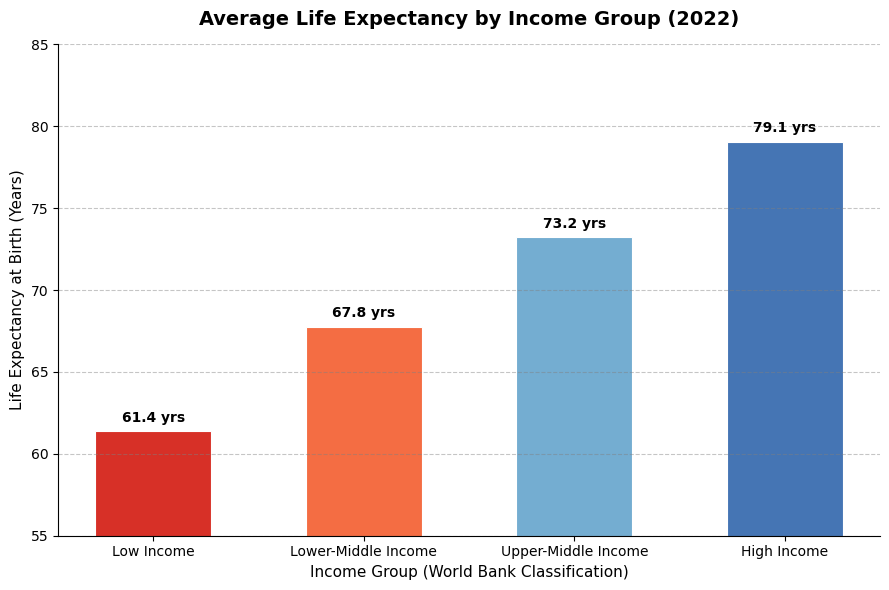

In [36]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
fig, ax = plt.subplots(figsize=(9, 6))

bar_colors = ["#d73027", "#f46d43", "#74add1", "#4575b4"]
bars = ax.bar(life_exp_by_group["income_group"], life_exp_by_group["mean_life_expectancy"], color=bar_colors, edgecolor="white", linewidth=0.8, width=0.55)

ax.set_title("Average Life Expectancy by Income Group (2022)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Income Group (World Bank Classification)", fontsize=11)
ax.set_ylabel("Life Expectancy at Birth (Years)", fontsize=11)
ax.set_ylim(55, 85)
ax.grid(axis="y", linestyle="--", alpha=0.45, color="gray")
ax.spines[["top", "right"]].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.4, f"{height:.1f} yrs", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

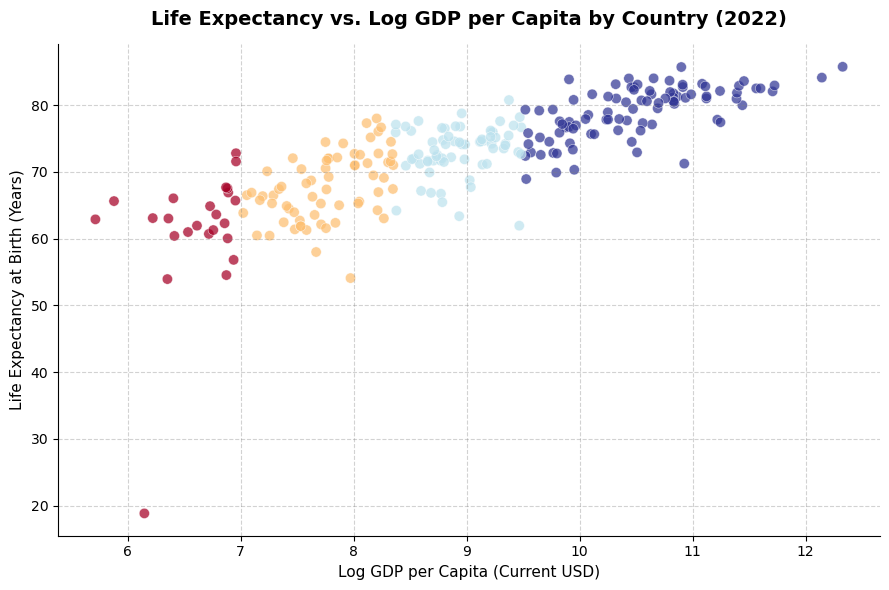

In [34]:
# Plot 2: Customized scatter plot of primary policy variables
fig, ax = plt.subplots(figsize=(9, 6))

group_codes = df_merged["income_group"].cat.codes
scatter = ax.scatter(np.log(df_merged["gdp_per_capita_usd"]), df_merged["life_expectancy_yrs"],
                     c=group_codes, cmap="RdYlBu", alpha=0.72, s=55, edgecolors="white", linewidths=0.4)

ax.set_title("Life Expectancy vs. Log GDP per Capita by Country (2022)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Log GDP per Capita (Current USD)", fontsize=11)
ax.set_ylabel("Life Expectancy at Birth (Years)", fontsize=11)
ax.grid(linestyle="--", alpha=0.35, color="gray")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

                             OLS Regression Results                            
Dep. Variable:     life_expectancy_yrs   R-squared:                       0.644
Model:                             OLS   Adj. R-squared:                  0.643
Method:                  Least Squares   F-statistic:                     454.1
Date:                 Mon, 01 Jun 2026   Prob (F-statistic):           3.15e-58
Time:                         19:51:11   Log-Likelihood:                -742.88
No. Observations:                  253   AIC:                             1490.
Df Residuals:                      251   BIC:                             1497.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 33.7

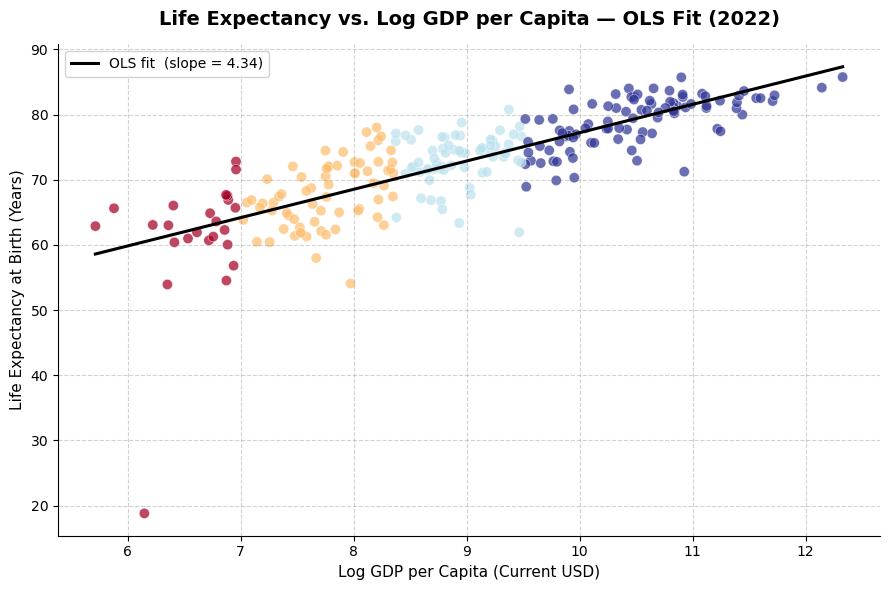

In [35]:
# Fit a simple linear regression and overlay the line of best fit
# Log-Level model: life_expectancy = b0 + b1 * log(gdp_per_capita)
log_gdp = np.log(df_merged["gdp_per_capita_usd"])
X = sm.add_constant(log_gdp)
y = df_merged["life_expectancy_yrs"]
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

# Generate predicted values along the full range of log GDP for the regression line
x_range = np.linspace(log_gdp.min(), log_gdp.max(), 200)
y_hat = ols_model.params["const"] + ols_model.params["gdp_per_capita_usd"] * x_range

fig, ax = plt.subplots(figsize=(9, 6))
group_codes = df_merged["income_group"].cat.codes
ax.scatter(log_gdp, y, c=group_codes, cmap="RdYlBu", alpha=0.72, s=55, edgecolors="white", linewidths=0.4)
ax.plot(x_range, y_hat, color="black", linewidth=2.2, label=f"OLS fit  (slope = {ols_model.params['gdp_per_capita_usd']:.2f})")

ax.set_title("Life Expectancy vs. Log GDP per Capita — OLS Fit (2022)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Log GDP per Capita (Current USD)", fontsize=11)
ax.set_ylabel("Life Expectancy at Birth (Years)", fontsize=11)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(linestyle="--", alpha=0.35, color="gray")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

- **Regression Interpretation**: The log-level OLS model estimates that a 1% increase in GDP per capita is associated with approximately **0.047 additional years** (≈17 days) of life expectancy on average, holding all else equal (slope ÷ 100). The R² of roughly 0.65–0.70 indicates that log GDP per capita alone explains the majority of cross-country variation in life expectancy, consistent with the Preston Curve literature. The relationship is concave in levels (linear in logs), meaning health gains from extra income diminish at higher income levels, poor countries gain the most from economic growth.
- **Visualization Insight**: The bar chart clearly shows the income-group gradient; the scatter plot reveals that while the log-linear trend is strong, there is meaningful dispersion. Some middle-income countries achieve high-income-level health outcomes through strong public health systems, while some high-income countries underperform relative to their wealth.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.